# 04 - Bandpass sampling study

Purpose of notebook:
- Determine empirically the extent of spectral leakage outside f1 and f2 for chirplets that span the design constraints
- From this data, determine a bandwidth parameter for safe (from aliasing) bandpass sampling
- Perform bandpass sampling via complex demodulation and inspect I & Q (envelope and phase parts of the resampling op)

In [1]:
# Imports

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

from util import pchirp, pick_bw_fc, bw_fc_to_f1f2, pick_val
from util import MAX_DUR_MS, MIN_DUR_MS, MAX_DEGREE, MIN_DEGREE, FS

%matplotlib widget

plt.close('all')

## Method

- Spectral leakage will be determined by the kernel (filter) frequency content
- Each kernel will thus be zero padded to a common length to increase freq resolution and simply FFT'ed to inspect content compared to intended f1 - f2 range

In [2]:
# Helper method - compute actual bandwidth of signal
#  - finds X dB down frequencies in response, where X is threshold compared to 0 dB

def get_bw_actual(signal, threshold_dB, samplerate=16000):
    f = np.fft.rfftfreq(len(signal), 1. / FS)
    x = np.fft.rfft(signal)
    X = 20 * np.log10(np.abs(x) + 1e-12)
    X -= np.max(X)
    idx = np.argmax(X)

    if np.min(X[:idx]) > threshold_dB:
        print("Left side of fc did not reach threshold")
        return (np.nan, np.nan)
    if np.min(X[idx:]) > threshold_dB:
        print("Right side of fc did not reach threshold")
        return (np.nan, np.nan)
        
    i = idx
    a = 0
    while i > 0 and a > threshold_dB:
        i -= 1
        a = X[i]
    f1 = f[i]
    i = idx
    a = 0
    while i < len(f) and a > threshold_dB:
        i += 1
        a = X[i]
    f2 = f[i]

    return (f1, f2)

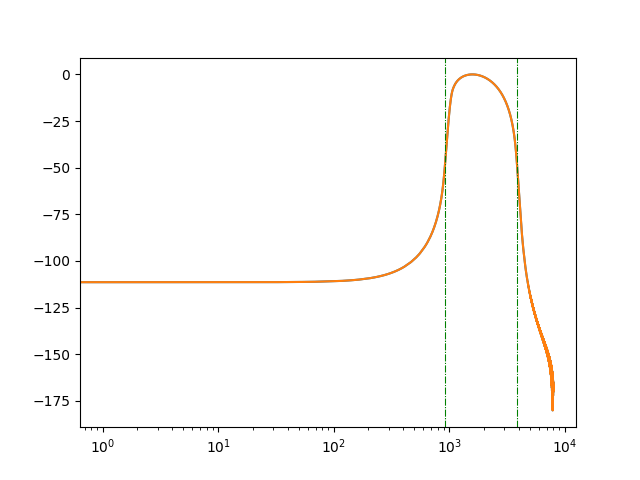

In [6]:
# Test get_bw_actual on example chirplet

T = 1.0
ch = pchirp(1000., 4000., 100., 2.)
chp = np.zeros(int(FS * T))
chp[:len(ch)] = ch
L = len(chp)

f = np.fft.rfftfreq(L, 1. / FS)
x = np.fft.rfft(chp)
X = 20 * np.log10(np.abs(x) + 1e-12)
X -= np.max(X)

F1, F2 = get_bw_actual(chp, -50)

plt.semilogx(f, X)
plt.axvline(F1, color='g', linestyle='-.', linewidth=0.75)
plt.axvline(F2, color='g', linestyle='-.', linewidth=0.75)
plt.grid(which='both')
plt.show()

In [4]:
# Generate many chirplets and collect data
N = 5000
data = []

for i in range(N):
    if i % 100 == 0:
        print(f"Iter: {i:>4} / {N}")

    # Generate chirp
    dur = pick_val(MIN_DUR_MS, MAX_DUR_MS)
    deg = pick_val(MIN_DEGREE, MAX_DEGREE)
    bw, fc = pick_bw_fc()
    f1, f2 = bw_fc_to_f1f2(bw, fc)
    ch = pchirp(f1, f2, dur, deg)
    chp = np.pad(ch, (0, int(FS * T - len(ch))))

    # Compute bw with leakage
    F1_40, F2_40 = get_bw_actual(chp, -40)
    F1_45, F2_45 = get_bw_actual(chp, -45)
    F1_50, F2_50 = get_bw_actual(chp, -50)

    # Store
    d = {}
    d["chirp"] = ch
    d["duration_ms"] = dur
    d["degree"] = deg
    d["bw"] = bw
    d["fc"] = fc
    d["f1f2"] = (np.min([f1, f2]), np.max([f1, f2]))
    d["f1f2_40"] = (F1_40, F2_40)
    d["f1f2_45"] = (F1_45, F2_45)
    d["f1f2_50"] = (F1_50, F2_50)